In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import gzip
from tqdm import tqdm
import os
import re

metadata = pd.read_csv('../code/resources/GTEx/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt', sep='\t')
metadata_rin = metadata[['SAMPID', 'SMRIN']]
metadata_rin.columns = ['entity:sample_id', 'RIN']

(array([2.000e+00, 0.000e+00, 1.400e+01, 1.312e+03, 4.122e+03, 4.954e+03,
        4.431e+03, 2.968e+03, 1.096e+03, 1.099e+03]),
 array([ 3.1 ,  3.79,  4.48,  5.17,  5.86,  6.55,  7.24,  7.93,  8.62,
         9.31, 10.  ]),
 <BarContainer object of 10 artists>)

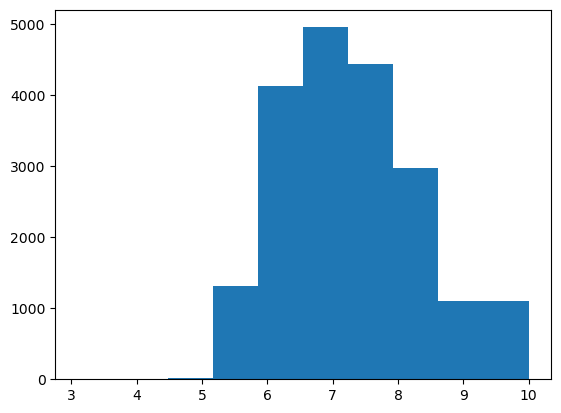

In [2]:
plt.hist(np.array(metadata_rin.dropna().RIN))

In [3]:
metadata['tissue_id'] = metadata.SMTSD.apply(lambda x: re.sub('\)', '', re.sub('\(', '_', re.sub(
    ' ', '', x))))

<>:1: SyntaxWarning: invalid escape sequence '\)'
<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\)'
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_459801/1357720594.py:1: SyntaxWarning: invalid escape sequence '\)'
  metadata['tissue_id'] = metadata.SMTSD.apply(lambda x: re.sub('\)', '', re.sub('\(', '_', re.sub(
/tmp/ipykernel_459801/1357720594.py:1: SyntaxWarning: invalid escape sequence '\('
  metadata['tissue_id'] = metadata.SMTSD.apply(lambda x: re.sub('\)', '', re.sub('\(', '_', re.sub(


In [4]:
tissues_49 = sorted(set([x.split('.')[0] for x in os.listdir(
    '/project/yangili1/cfbuenabadn/SpliFi/code/resources/GTEx/juncs/all49tissues/')]))

In [5]:
samples = []
for idx, row in metadata.iterrows():
    indiv_id = '-'.join(row.SAMPID.split('-')[:2])
    file_name = row.tissue_id + '.' + indiv_id + '.tsv.gz'
    samples.append(file_name)

metadata['file_name'] = samples

In [6]:
rin_bin = []
for idx, row in metadata.iterrows():
    if (row.SMRIN >= 5) & (row.SMRIN < 6):
        rin_bin.append('RIN5-6')
    elif (row.SMRIN >= 6) & (row.SMRIN < 7):
        rin_bin.append('RIN6-7')
    elif (row.SMRIN >= 7) & (row.SMRIN < 8):
        rin_bin.append('RIN7-8')
    elif (row.SMRIN >= 8) & (row.SMRIN < 9):
        rin_bin.append('RIN8-9')
    elif (row.SMRIN >= 9):
        rin_bin.append('RIN9-10')
    else:
        rin_bin.append('other')

metadata['rin_bin'] = rin_bin

In [7]:
rins = metadata.groupby('file_name').rin_bin.unique()
keep_files = []
for x in metadata.groupby('file_name').rin_bin.unique():
    if len(x) == 1:
        keep_files.append(True)
    else:
        keep_files.append(False)

In [8]:
# metadata.loc[metadata.file_name.isin(rins.loc[keep_files].index)]

In [9]:
tissues_to_sample = []

for tissue in tissues_49:
    add_tissue = True
    meta_tissue = metadata.loc[metadata.file_name.isin(os.listdir(
    '/project/yangili1/cfbuenabadn/SpliFi/code/resources/GTEx/juncs/all49tissues/')
                                        ) & (metadata.tissue_id == tissue) & metadata.file_name.isin(rins.loc[keep_files].index)]
    add_tissue = add_tissue and (len(meta_tissue.loc[(meta_tissue.SMRIN >= 5) & (meta_tissue.SMRIN < 6)].file_name) >= 2)
    add_tissue = add_tissue and (len(meta_tissue.loc[(meta_tissue.SMRIN >= 6) & (meta_tissue.SMRIN < 7)].file_name) >= 2)
    add_tissue = add_tissue and (len(meta_tissue.loc[(meta_tissue.SMRIN >= 7) & (meta_tissue.SMRIN < 8)].file_name) >= 2)
    add_tissue = add_tissue and (len(meta_tissue.loc[(meta_tissue.SMRIN >= 8) & (meta_tissue.SMRIN < 9)].file_name) >= 2)
    add_tissue = add_tissue and (len(meta_tissue.loc[(meta_tissue.SMRIN >= 9) & (meta_tissue.SMRIN <= 10)].file_name) >= 2)

    if add_tissue:
        tissues_to_sample.append(tissue)

In [10]:
# tissues_to_sample

In [11]:
fh_RIN5 = open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/GTEx_RIN5-6_files.txt', 'w')
fh_RIN6 = open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/GTEx_RIN6-7_files.txt', 'w')
fh_RIN7 = open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/GTEx_RIN7-8_files.txt', 'w')
fh_RIN8 = open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/GTEx_RIN8-9_files.txt', 'w')
fh_RIN9 = open('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/config/GTEx_RIN9-10_files.txt', 'w')

filepath = '/project/yangili1/cfbuenabadn/SpliFi/code/resources/GTEx/juncs/all49tissues/'

for tissue in tissues_to_sample:
    meta_tissue = metadata.loc[metadata.file_name.isin(os.listdir(filepath)
                                                      ) & (metadata.tissue_id == tissue) & metadata.file_name.isin(rins.loc[keep_files].index)]

    rin5 = list(meta_tissue.loc[(meta_tissue.SMRIN >= 5) & (meta_tissue.SMRIN < 6)].file_name)
    rin5 = [filepath + x+'\n' for x in np.random.choice(rin5, 2, replace = False)]

    fh_RIN5.writelines(rin5)

    rin6 = list(meta_tissue.loc[(meta_tissue.SMRIN >= 6) & (meta_tissue.SMRIN < 7)].file_name)
    rin6 = [filepath + x+'\n' for x in np.random.choice(rin6, 2, replace = False)]

    fh_RIN6.writelines(rin6)

    rin7 = list(meta_tissue.loc[(meta_tissue.SMRIN >= 7) & (meta_tissue.SMRIN < 8)].file_name)
    rin7 = [filepath + x+'\n' for x in np.random.choice(rin7, 2, replace = False)]

    fh_RIN7.writelines(rin7)

    rin8 = list(meta_tissue.loc[(meta_tissue.SMRIN >= 8) & (meta_tissue.SMRIN < 9)].file_name)
    rin8 = [filepath + x+'\n' for x in np.random.choice(rin8, 2, replace = False)]

    fh_RIN8.writelines(rin8)

    rin9 = list(meta_tissue.loc[(meta_tissue.SMRIN >= 9)].file_name)
    rin9 = [filepath + x+'\n' for x in np.random.choice(rin9, 2, replace = False)]

    fh_RIN9.writelines(rin9)

fh_RIN5.close()
fh_RIN6.close()
fh_RIN7.close()
fh_RIN8.close()
fh_RIN9.close()


In [12]:
len(tissues_to_sample)

32

In [13]:
def get_juncs_by_gene(RIN):
    bed = []
    ms_juncs = []
    ms_class = []
    with gzip.open(f'/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/{RIN}/leafcutter2.junction_counts.const.gz',
                   'rb') as ms:
        ms.readline()
        for linea in tqdm(ms):
            row = linea.decode().split(' ')
            junc = row[0]
            chrom, start, end, clu, annot = junc.split(':')
            strand = clu.split('_')[-1]
    
            out_junc = ':'.join([chrom, start, end, strand])
    
            ms_juncs.append(out_junc)
            ms_class.append(annot)
    
            
    
            counts = [int(x) for x in row[1:]]
            sum_counts = np.sum(counts)
    
            bed_row = [chrom, start, end, out_junc, annot, strand, sum_counts, clu]
            bed.append(bed_row)
    
    
    introns_df = pd.DataFrame(bed, columns = ['chrom', 'start', 'end', 'junc', 'annot', 'strand', 'counts', 'cluster'])
    
    return introns_df

In [14]:
introns_df_rin5 = get_juncs_by_gene('RIN5-6')
introns_df_rin6 = get_juncs_by_gene('RIN6-7')
introns_df_rin7 = get_juncs_by_gene('RIN7-8')
introns_df_rin8 = get_juncs_by_gene('RIN8-9')
introns_df_rin9 = get_juncs_by_gene('RIN9-10')

250996it [00:05, 46569.82it/s]
255619it [00:05, 45012.72it/s]
257801it [00:05, 45712.13it/s]
259101it [00:05, 45194.88it/s]
262813it [00:05, 45298.28it/s]


In [7]:
introns_merged = introns_df_rin5.merge(introns_df_rin9, on='junc')

In [8]:
introns_merged.loc[introns_merged.annot_y == 'UP'].annot_x.value_counts()

annot_x
UP    13915
PR        2
Name: count, dtype: int64

In [230]:
introns_merged.loc[(introns_merged.annot_y == 'UP') & (introns_merged.annot_x == 'PR')]

,chrom_x,start_x,end_x,junc,annot_x,strand_x,counts_x,cluster_x,chrom_y,start_y,end_y,annot_y,strand_y,counts_y,cluster_y
118835,chr9,133207336,133207839,chr9:133207336:133207839:-,PR,-,85,clu_84405_-,chr9,133207336,133207839,UP,-,78,clu_87042_-
118837,chr9,133207945,133208132,chr9:133207945:133208132:-,PR,-,32,clu_84405_-,chr9,133207945,133208132,UP,-,31,clu_87042_-


In [227]:
introns_df_rin5.loc[introns_df_rin5.cluster == 'clu_84405_-']

,chrom,start,end,junc,annot,strand,counts,cluster
120728,chr9,133207336,133207839,chr9:133207336:133207839:-,PR,-,85,clu_84405_-
120729,chr9,133207336,133208132,chr9:133207336:133208132:-,PR,-,187,clu_84405_-
120730,chr9,133207945,133208132,chr9:133207945:133208132:-,PR,-,32,clu_84405_-


In [232]:
introns_df_rin9.loc[introns_df_rin9.cluster == 'clu_87042_-']

,chrom,start,end,junc,annot,strand,counts,cluster
126679,chr9,133207336,133207839,chr9:133207336:133207839:-,UP,-,78,clu_87042_-
126680,chr9,133207336,133208132,chr9:133207336:133208132:-,PR,-,88,clu_87042_-
126681,chr9,133207945,133208132,chr9:133207945:133208132:-,UP,-,31,clu_87042_-


In [15]:
class_rin9 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/RIN9-10/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')
class_rin5 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/RIN5-6/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')

class_rin6 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/RIN6-7/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')

class_rin7 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/RIN7-8/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')

class_rin8 = pd.read_csv('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/RIN/RIN8-9/clustering/leafcutter2_junction_classifications.txt',
                         sep='\t')

In [16]:
class_rin5['junc_gene'] = class_rin5.Intron_coord + ':' + class_rin5.Strand + ':' + class_rin5.Gene_name
class_rin6['junc_gene'] = class_rin6.Intron_coord + ':' + class_rin6.Strand + ':' + class_rin6.Gene_name
class_rin7['junc_gene'] = class_rin7.Intron_coord + ':' + class_rin7.Strand + ':' + class_rin7.Gene_name
class_rin8['junc_gene'] = class_rin8.Intron_coord + ':' + class_rin8.Strand + ':' + class_rin8.Gene_name
class_rin9['junc_gene'] = class_rin9.Intron_coord + ':' + class_rin9.Strand + ':' + class_rin9.Gene_name

class_rin5['junc'] = class_rin5.Intron_coord + ':' + class_rin5.Strand #+ ':' + class_rin5.Gene_name
class_rin6['junc'] = class_rin6.Intron_coord + ':' + class_rin6.Strand #+ ':' + class_rin6.Gene_name
class_rin7['junc'] = class_rin7.Intron_coord + ':' + class_rin7.Strand #+ ':' + class_rin7.Gene_name
class_rin8['junc'] = class_rin8.Intron_coord + ':' + class_rin8.Strand #+ ':' + class_rin8.Gene_name
class_rin9['junc'] = class_rin9.Intron_coord + ':' + class_rin9.Strand #+ ':' + class_rin9.Gene_name

In [17]:
rins_list = [class_rin5, class_rin6, class_rin7, class_rin8, class_rin9]

In [24]:
rin_df = []
for rin1 in rins_list:
    rin_row = []
    for rin2 in rins_list:
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = (~rin_class_merged.loc[rin_class_merged.Coding_x == True].Coding_y).sum()
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

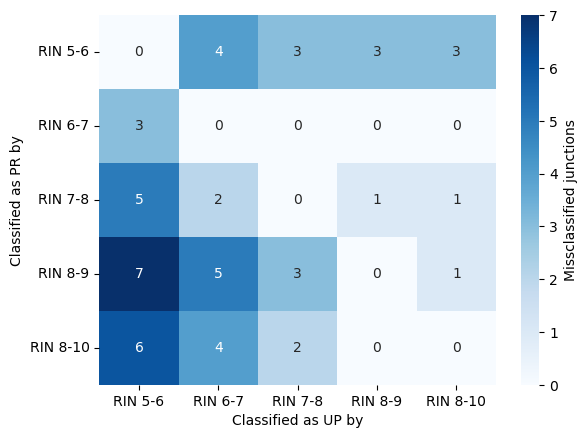

In [26]:
g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'}, cmap='Blues')
g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by')
g.axes.set_xlabel('Classified as UP by')

plt.savefig('../code/revision_plots/RIN_BFS_misclassification.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification.svg', dpi=300, bbox_inches='tight')    

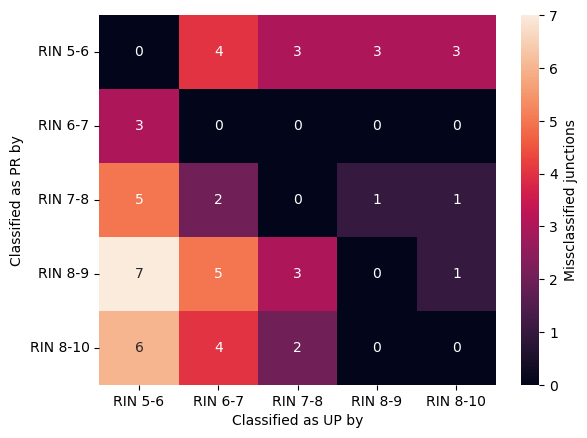

In [29]:
g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missclassified junctions'})
g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by')
g.axes.set_xlabel('Classified as UP by')

plt.savefig('../code/revision_plots/RIN_BFS_misclassification.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification.svg', dpi=300, bbox_inches='tight')    

In [30]:
rin_df = []
for rin1 in rins_list:
    rin_row = []
    for rin2 in rins_list:
        rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        pct_PR = 100*(~rin_class_merged.loc[rin_class_merged.Coding_x == True].Coding_y).mean()
        rin_row.append(pct_PR)
    rin_df.append(rin_row)

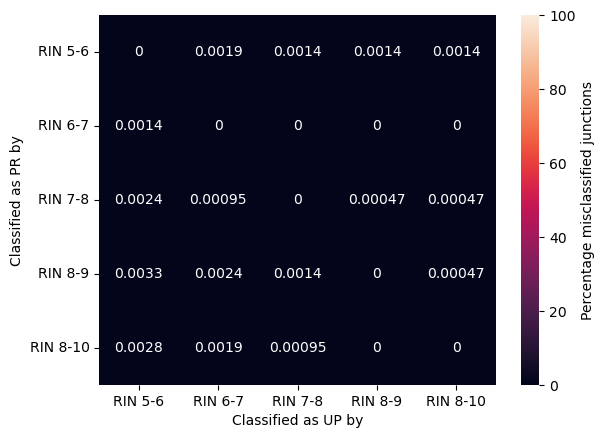

In [31]:
g = sns.heatmap(pd.DataFrame(rin_df), annot = True, vmax=100, cbar_kws={'label': 'Percentage misclassified junctions'})
g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Classified as PR by')
g.axes.set_xlabel('Classified as UP by')

plt.savefig('../code/revision_plots/RIN_BFS_misclassification_pct.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification_pct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_BFS_misclassification_pct.svg', dpi=300, bbox_inches='tight')    

In [20]:
rin_df = []
for rin1 in rins_list:
    rin_row = []
    for rin2 in rins_list:
        # rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        missing_juncs = len(pd.Index(rin1.junc.unique()).difference(pd.Index(rin2.junc.unique())))
        rin_row.append(missing_juncs)
    rin_df.append(rin_row)

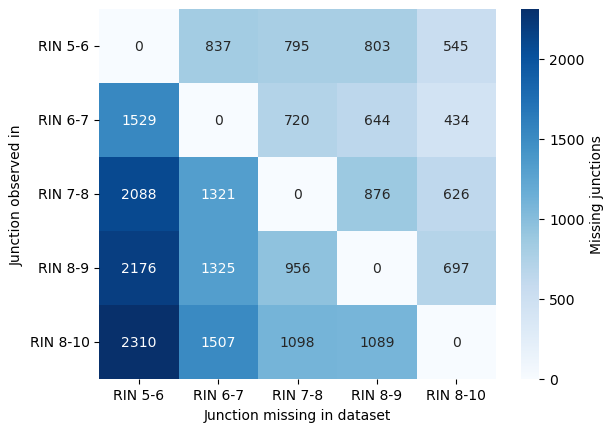

In [22]:
g = sns.heatmap(pd.DataFrame(rin_df), annot = True, fmt = 'd', cbar_kws={'label': 'Missing junctions'}, cmap='Blues')
g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Junction observed in')
g.axes.set_xlabel('Junction missing in dataset')

plt.savefig('../code/revision_plots/RIN_missing_junctions.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_missing_junctions.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_missing_junctions.svg', dpi=300, bbox_inches='tight')

In [34]:
rin_df = []
for rin1 in rins_list:
    rin_row = []
    for rin2 in rins_list:
        # rin_class_merged = rin1.merge(rin2, on = 'junc_gene')
        missing_juncs = 100*len(pd.Index(rin1.junc.unique()).difference(pd.Index(rin2.junc.unique())))/len(pd.Index(rin1.junc.unique()))
        rin_row.append(missing_juncs)
    rin_df.append(rin_row)

In [36]:
rin_df

[[0.0,
  0.27179648710346777,
  0.2581579537004264,
  0.26075576958672,
  0.1769762072537514],
 [0.49539435529074044,
  0.0,
  0.23327922551297128,
  0.2086553072643799,
  0.1406155331564299],
 [0.6751949916570734,
  0.4271707777677174,
  0.0,
  0.283271462017048,
  0.20242914979757085],
 [0.703469501234951,
  0.42835344169867196,
  0.3090610492557965,
  0.0,
  0.22533007461432025],
 [0.7458445801960506,
  0.4865747975564711,
  0.3545183329243565,
  0.3516124449495667,
  0.0]]

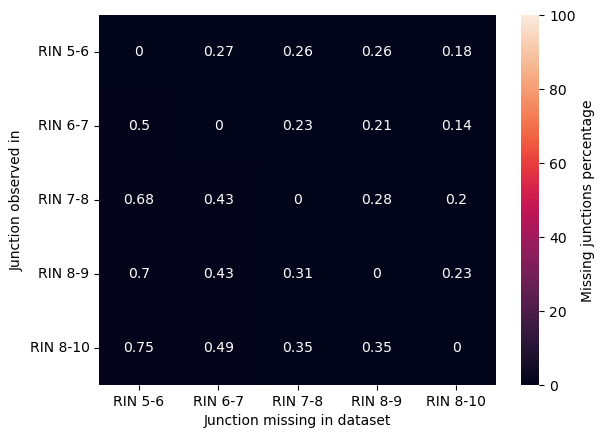

In [37]:
g = sns.heatmap(pd.DataFrame(rin_df), annot = True, cbar_kws={'label': 'Missing junctions percentage'}, vmax=100)
g.axes.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'])
g.axes.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5], ['RIN 5-6', 'RIN 6-7', 'RIN 7-8', 'RIN 8-9', 'RIN 8-10'], rotation=0)
g.axes.set_ylabel('Junction observed in')
g.axes.set_xlabel('Junction missing in dataset')

plt.savefig('../code/revision_plots/RIN_missing_junctions_pct.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_missing_junctions_pct.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/revision_plots/RIN_missing_junctions_pct.svg', dpi=300, bbox_inches='tight')

In [336]:
np.mean([x not in list(class_rin9.junc) for x in class_rin5.junc.unique()])

KeyboardInterrupt: 

In [340]:
len(pd.Index(class_rin5.junc.unique()).difference(pd.Index(class_rin9.junc.unique())))

545

In [268]:
rin_class_merged = rin1.merge(rin2, on = 'junc')

(318188, 8)

In [269]:
class_rin6.shape

(317444, 8)

In [267]:
class_rin9.shape

(318653, 8)

In [290]:
class_rin9.value_counts('junc').sort_values().iloc[-30:]

junc
chr2:233729993-233767033:+     9
chr2:233719687-233767033:+     9
chr5:140969331-140978948:+    15
chr5:141009728-141010165:+    15
chr5:140982563-141009626:+    15
chr5:140929325-140978948:+    15
chr5:140884662-140978948:+    15
chr5:140979007-140982474:+    15
chr5:141476146-141476530:+    20
chr5:141476146-141476970:+    20
chr5:141476146-141478393:+    20
chr5:141485185-141485309:+    21
chr5:141476146-141494806:+    22
chr5:141433183-141494806:+    22
chr5:141423660-141494806:+    22
chr5:141485185-141494806:+    22
chr5:141494865-141505392:+    22
chr5:141478546-141494806:+    22
chr5:141423105-141494806:+    22
chr5:141491700-141494806:+    22
chr5:141420274-141494806:+    22
chr5:141487615-141494806:+    22
chr5:141415611-141494806:+    22
chr5:141505481-141507103:+    22
chr5:141410620-141494806:+    22
chr5:141405376-141494806:+    22
chr5:141400524-141494806:+    22
chr5:141395237-141494806:+    22
chr5:141505481-141510946:+    22
chr5:141508283-141510946:+    22
Name:

In [293]:
class_rin9.loc[class_rin9.junc == 'chr5:141508283-141510946:+']

,Gene_name,Intron_coord,Strand,Annot,Coding,UTR,GencodePC,junc
92781,PCDHGA1,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92804,PCDHGA2,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92828,PCDHGA3,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92851,PCDHGB1,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92874,PCDHGA4,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92897,PCDHGB2,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92920,PCDHGA5,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92943,PCDHGB3,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92966,PCDHGA6,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+
92989,PCDHGA7,chr5:141508283-141510946,+,False,False,True,False,chr5:141508283-141510946:+


In [292]:
class_rin9.loc[class_rin9.junc == 'chr2:233729993-233767033:+']

,Gene_name,Intron_coord,Strand,Annot,Coding,UTR,GencodePC,junc
42206,UGT1A8,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42222,UGT1A10,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42237,UGT1A9,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42253,UGT1A7,chr2:233729993-233767033,+,False,False,True,False,chr2:233729993-233767033:+
42270,UGT1A6,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42283,UGT1A5,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42295,UGT1A4,chr2:233729993-233767033,+,False,False,False,False,chr2:233729993-233767033:+
42307,UGT1A3,chr2:233729993-233767033,+,True,True,False,True,chr2:233729993-233767033:+
42318,UGT1A1,chr2:233729993-233767033,+,False,False,True,False,chr2:233729993-233767033:+
